In [59]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [60]:
df = pd.read_csv("/Users/shubhamkumar/Downloads/creditcard.csv")

print(df.shape)

(284807, 31)


In [61]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (284807, 30)
y shape: (284807,)


In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (227845, 30)
X_test : (56962, 30)
y_train: (227845,)
y_test : (56962,)


In [63]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [64]:
rf_model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [65]:
import joblib
import os

# Create models folder if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save the newly trained model
joblib.dump(
    rf_model,
    "../models/fraud_detection_model.pkl"
)

# Save feature names
feature_names = X.columns.tolist()

joblib.dump(
    feature_names,
    "../models/feature_names.pkl"
)

# Save model configuration
model_config = {
    "threshold": 0.5
}

joblib.dump(
    model_config,
    "../models/model_config.pkl"
)

print("Model saved successfully!")
print("Number of features:", len(feature_names))
print("Threshold:", model_config["threshold"])

Model saved successfully!
Number of features: 30
Threshold: 0.5


In [66]:
y_pred_rf = rf_model.predict(X_test)

print(y_pred_rf[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [67]:
print("Predicted normal:", (y_pred_rf == 0).sum())
print("Predicted fraud :", (y_pred_rf == 1).sum())

Predicted normal: 56877
Predicted fraud : 85


In [68]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[56859     5]
 [   18    80]]


In [69]:
print("True Negatives :", cm_rf[0, 0])
print("False Positives:", cm_rf[0, 1])
print("False Negatives:", cm_rf[1, 0])
print("True Positives  :", cm_rf[1, 1])

True Negatives : 56859
False Positives: 5
False Negatives: 18
True Positives  : 80


In [70]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1 Score :", f1_rf)

Accuracy : 0.9995962220427653
Precision: 0.9411764705882353
Recall   : 0.8163265306122449
F1 Score : 0.8743169398907104


In [71]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

   Feature  Importance
17     V17    0.170325
14     V14    0.136363
12     V12    0.133326
10     V10    0.074073
16     V16    0.071792
11     V11    0.045277
9       V9    0.031127
4       V4    0.030496
18     V18    0.028156
7       V7    0.024627
26     V26    0.019624
3       V3    0.019525
21     V21    0.018656
1       V1    0.015333
2       V2    0.014775
6       V6    0.013451
0     Time    0.013033
27     V27    0.012989
20     V20    0.012957
8       V8    0.012564
22     V22    0.012268
29  Amount    0.012021
15     V15    0.011888
19     V19    0.010362
28     V28    0.010269
13     V13    0.010175
5       V5    0.009922
23     V23    0.008443
24     V24    0.008300
25     V25    0.007881


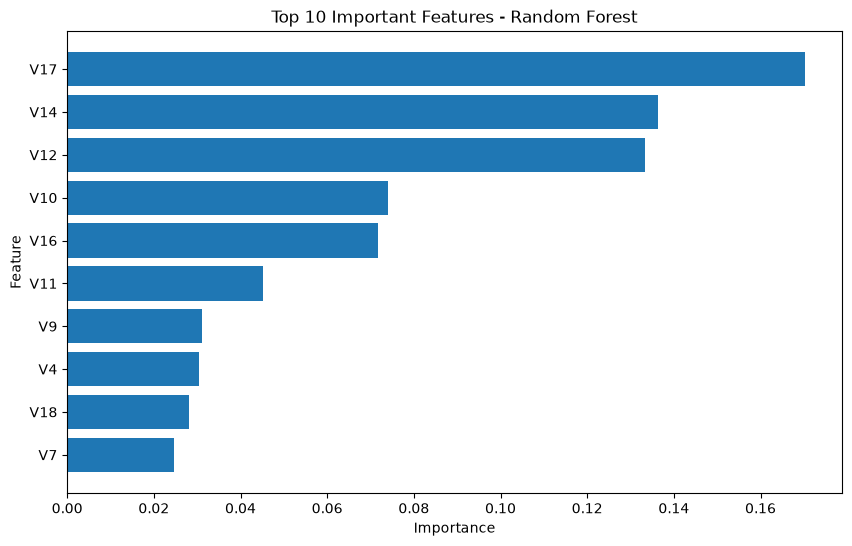

In [72]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features - Random Forest")

plt.show()

In [73]:
y_train_pred_rf = rf_model.predict(X_train)

train_accuracy = accuracy_score(y_train, y_train_pred_rf)
test_accuracy = accuracy_score(y_test, y_pred_rf)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy :", test_accuracy)

Training Accuracy: 1.0
Testing Accuracy : 0.9995962220427653


In [74]:
train_precision = precision_score(y_train, y_train_pred_rf)
train_recall = recall_score(y_train, y_train_pred_rf)
train_f1 = f1_score(y_train, y_train_pred_rf)

print("Training Precision:", train_precision)
print("Training Recall   :", train_recall)
print("Training F1 Score :", train_f1)

Training Precision: 1.0
Training Recall   : 1.0
Training F1 Score : 1.0


In [75]:
rf_model_tuned = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

In [76]:
rf_model_tuned.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total n

In [77]:
y_pred_rf_tuned = rf_model_tuned.predict(X_test)

print("Predicted normal:", (y_pred_rf_tuned == 0).sum())
print("Predicted fraud :", (y_pred_rf_tuned == 1).sum())

Predicted normal: 56877
Predicted fraud : 85


In [78]:
cm_rf_tuned = confusion_matrix(y_test, y_pred_rf_tuned)

print(cm_rf_tuned)

print("True Negatives :", cm_rf_tuned[0, 0])
print("False Positives:", cm_rf_tuned[0, 1])
print("False Negatives:", cm_rf_tuned[1, 0])
print("True Positives  :", cm_rf_tuned[1, 1])

[[56860     4]
 [   17    81]]
True Negatives : 56860
False Positives: 4
False Negatives: 17
True Positives  : 81


In [79]:
accuracy_rf_tuned = accuracy_score(y_test, y_pred_rf_tuned)
precision_rf_tuned = precision_score(y_test, y_pred_rf_tuned)
recall_rf_tuned = recall_score(y_test, y_pred_rf_tuned)
f1_rf_tuned = f1_score(y_test, y_pred_rf_tuned)

print("Accuracy :", accuracy_rf_tuned)
print("Precision:", precision_rf_tuned)
print("Recall   :", recall_rf_tuned)
print("F1 Score :", f1_rf_tuned)

Accuracy : 0.9996313331694814
Precision: 0.9529411764705882
Recall   : 0.826530612244898
F1 Score : 0.8852459016393442


In [80]:
y_train_pred_rf_tuned = rf_model_tuned.predict(X_train)

train_precision_tuned = precision_score(y_train, y_train_pred_rf_tuned)
train_recall_tuned = recall_score(y_train, y_train_pred_rf_tuned)
train_f1_tuned = f1_score(y_train, y_train_pred_rf_tuned)

print("Training Precision:", train_precision_tuned)
print("Training Recall   :", train_recall_tuned)
print("Training F1 Score :", train_f1_tuned)

Training Precision: 0.993920972644377
Training Recall   : 0.8299492385786802
Training F1 Score : 0.9045643153526971


In [81]:
from sklearn.metrics import roc_auc_score

y_prob_rf = rf_model_tuned.predict_proba(X_test)[:, 1]

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("ROC-AUC Score:", roc_auc_rf)

ROC-AUC Score: 0.9798014309831979


In [82]:
from sklearn.metrics import average_precision_score

pr_auc_rf = average_precision_score(y_test, y_prob_rf)

print("PR-AUC Score:", pr_auc_rf)

PR-AUC Score: 0.8679803329289035


In [83]:
# Save real test-set predictions for Streamlit dashboard

evaluation_data = pd.DataFrame({
    "Actual": y_test,
    "Probability": y_prob_rf
})

evaluation_data.to_csv(
    "../real_model_evaluation.csv",
    index=False
)

print("Real evaluation data saved successfully!")
print("Rows:", len(evaluation_data))

Real evaluation data saved successfully!
Rows: 56962


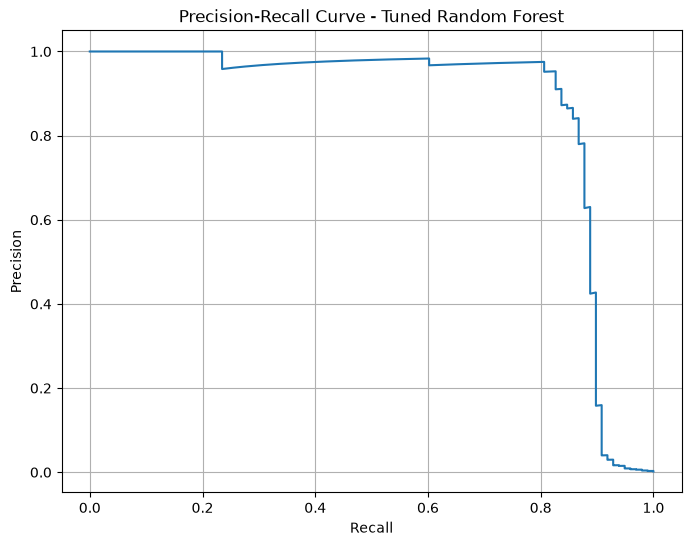

In [84]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(8, 6))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Tuned Random Forest")

plt.grid()
plt.show()

In [85]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(
    rf_model_tuned,
    "../models/fraud_detection_model.pkl"
)

print("Tuned model saved successfully!")

Tuned model saved successfully!


In [86]:
import os

print(os.path.exists("fraud_detection_model.pkl"))

True


In [87]:
import joblib

feature_names = X_train.columns.tolist()

joblib.dump(
    feature_names,
    "../models/feature_names.pkl"
)

print("Feature names saved successfully!")

Feature names saved successfully!


In [88]:
import os

print(os.path.exists("feature_names.pkl"))

True


In [89]:
import joblib

loaded_model = joblib.load("fraud_detection_model.pkl")

print("Model loaded successfully!")

Model loaded successfully!


In [90]:
sample_transaction = X_test.iloc[[0]]

prediction = loaded_model.predict(sample_transaction)

print("Prediction:", prediction)

Prediction: [0]


In [91]:
id="wq8p9a"
probability = loaded_model.predict_proba(sample_transaction)

print("Probability of Normal:", probability[0][0])
print("Probability of Fraud :", probability[0][1])

Probability of Normal: 0.9999474148981785
Probability of Fraud : 5.2585101821285e-05


In [92]:
def predict_fraud(transaction):
    prediction = loaded_model.predict(transaction)[0]
    probability = loaded_model.predict_proba(transaction)[0][1]

    if prediction == 1:
        result = "FRAUD"
    else:
        result = "NORMAL"

    print("Transaction:", result)
    print("Fraud Probability:", probability * 100, "%")

In [93]:
predict_fraud(sample_transaction)

Transaction: NORMAL
Fraud Probability: 0.005258510182128502 %


In [94]:
fraud_transaction = X_test[y_test == 1].iloc[[0]]

predict_fraud(fraud_transaction)

Transaction: FRAUD
Fraud Probability: 91.5642857142857 %


In [95]:
feature_names = joblib.load("feature_names.pkl")

print("Number of features:", len(feature_names))
print(feature_names)

Number of features: 30
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


In [96]:
def predict_transaction(transaction):
    transaction = transaction[feature_names]

    prediction = loaded_model.predict(transaction)[0]
    fraud_probability = loaded_model.predict_proba(transaction)[0][1]

    if prediction == 1:
        result = "FRAUD"
    else:
        result = "NORMAL"

    print("Transaction:", result)
    print(f"Fraud Probability: {fraud_probability * 100:.4f}%")

In [97]:
predict_transaction(sample_transaction)

Transaction: NORMAL
Fraud Probability: 0.0053%


In [98]:
predict_transaction(fraud_transaction)

Transaction: FRAUD
Fraud Probability: 91.5643%


In [99]:
print(feature_names)

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


In [100]:
def prepare_transaction(transaction_data):
    transaction = pd.DataFrame([transaction_data])

    # Make sure features are in the same order as training
    transaction = transaction[feature_names]

    return transaction

In [101]:
test_data = X_test.iloc[0].to_dict()

new_transaction = prepare_transaction(test_data)

print(new_transaction.shape)
print(new_transaction.columns.tolist())

(1, 30)
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


In [102]:
def detect_fraud(transaction_data):
    # Prepare the transaction
    transaction = prepare_transaction(transaction_data)

    # Prediction
    prediction = loaded_model.predict(transaction)[0]

    # Fraud probability
    fraud_probability = loaded_model.predict_proba(transaction)[0][1]

    if prediction == 1:
        result = "FRAUD"
    else:
        result = "NORMAL"

    return result, fraud_probability

In [103]:
result, probability = detect_fraud(test_data)

print("Transaction:", result)
print(f"Fraud Probability: {probability * 100:.4f}%")

Transaction: NORMAL
Fraud Probability: 0.0053%


In [104]:
def prepare_transaction(transaction_data):

    if isinstance(transaction_data, pd.DataFrame):
        transaction = transaction_data.copy()
    else:
        transaction = pd.DataFrame([transaction_data])

    transaction = transaction[feature_names]

    return transaction

In [105]:
result, probability = detect_fraud(fraud_transaction)

print("Transaction:", result)
print(f"Fraud Probability: {probability * 100:.4f}%")

Transaction: FRAUD
Fraud Probability: 91.5643%


In [106]:
import joblib

model_config = {
    "model_file": "fraud_detection_model.pkl",
    "feature_file": "feature_names.pkl",
    "threshold": 0.50
}

joblib.dump(
    model_config,
    "../models/model_config.pkl"
)

print("Model configuration saved successfully!")

Model configuration saved successfully!


In [107]:
import os

print(os.path.exists("model_config.pkl"))

True


In [108]:
import joblib

model = joblib.load("fraud_detection_model.pkl")
features = joblib.load("feature_names.pkl")
config = joblib.load("model_config.pkl")

print("Model loaded:", type(model).__name__)
print("Number of features:", len(features))
print("Threshold:", config["threshold"])

Model loaded: RandomForestClassifier
Number of features: 30
Threshold: 0.5


In [109]:
def predict_from_saved_model(transaction_data):
    transaction = prepare_transaction(transaction_data)

    probability = model.predict_proba(transaction)[0][1]

    if probability >= config["threshold"]:
        result = "FRAUD"
    else:
        result = "NORMAL"

    return result, probability

In [110]:
result, probability = predict_from_saved_model(test_data)

print("Transaction:", result)
print(f"Fraud Probability: {probability * 100:.4f}%")

Transaction: NORMAL
Fraud Probability: 0.0053%


In [111]:
result, probability = predict_from_saved_model(fraud_transaction)

print("Transaction:", result)
print(f"Fraud Probability: {probability * 100:.4f}%")

Transaction: FRAUD
Fraud Probability: 91.5643%


In [112]:
import os

print(os.getcwd())

/Users/shubhamkumar/Desktop/fraud-detection-system/notebooks


In [113]:
import os

print(os.listdir())

['01_Data_Exploration.ipynb', '02_random_forest.ipynb', 'fraud_detection_model.pkl', 'feature_names.pkl', 'model_config.pkl']


In [114]:
import pandas as pd

test_data = pd.read_csv(
    "/Users/shubhamkumar/Downloads/creditcard.csv"
).head(5)

test_data = test_data.drop(columns=["Class"])

test_data.to_csv(
    "/Users/shubhamkumar/Desktop/fraud-detection-system/test_transactions.csv",
    index=False
)

print(test_data.shape)

(5, 30)


In [115]:
import pandas as pd

# Load original dataset
df = pd.read_csv(
    "/Users/shubhamkumar/Downloads/creditcard.csv"
)

# Select 5 normal transactions
normal = df[df["Class"] == 0].head(5)

# Select 5 fraud transactions
fraud = df[df["Class"] == 1].head(5)

# Combine them
test_mixed = pd.concat(
    [normal, fraud],
    ignore_index=True
)

# Remove the actual answer column
test_mixed = test_mixed.drop(columns=["Class"])

# Save test file
test_mixed.to_csv(
    "/Users/shubhamkumar/Desktop/fraud-detection-system/test_mixed_transactions.csv",
    index=False
)

print(test_mixed.shape)

(10, 30)


In [116]:
import joblib

model = joblib.load("../models/fraud_detection_model.pkl")
features = joblib.load("../models/feature_names.pkl")
config = joblib.load("../models/model_config.pkl")

print("Model loaded:", type(model).__name__)
print("Number of features:", len(features))
print("Threshold:", config["threshold"])

Model loaded: RandomForestClassifier
Number of features: 30
Threshold: 0.5
